# Price of Used Toyota Corolla Cars(LogReg solution)

## **Target : Price**

    Id: Уникальный идентификатор для каждого автомобиля.
    Model: Модель Toyota Corolla.
    Price: Цена продажи подержанного автомобиля.
    Age_08_04: Возраст автомобиля в месяцах по состоянию на август 2004 года.
    Mfg_Month: Месяц производства автомобиля.
    Mfg_Year: Год производства автомобиля.
    KM: Пробег автомобиля в километрах.
    Fuel_type: Тип топлива (например, бензин, дизель).
    HP: Лошадиные силы, мера мощности двигателя.
    Met_Color: Бинарный индикатор металлической краски (0 = Нет, 1 = Да).
    Color: Цвет кузова автомобиля.
    Automatic: Бинарный индикатор автоматической коробки передач (0 = Нет, 1 = Да).
    CC: Объем двигателя в кубических сантиметрах.
    Doors: Количество дверей автомобиля.
    Cylinders: Количество цилиндров в двигателе.
    Gears: Количество передач в коробке передач.
    Quarterly: Ежеквартальный налог на автомобиль.
    Weight: Вес автомобиля.
    Mfr_Guarantee: Бинарный индикатор гарантии производителя (0 = Нет, 1 = Да).
    BOVAG_Guarantee: Бинарный индикатор гарантии BOVAG (0 = Нет, 1 = Да).
    Guarantee_Period: Срок гарантии в месяцах.
    ABS: Бинарный индикатор антиблокировочной тормозной системы (0 = Нет, 1 = Да).
    Airbag_1: Бинарный индикатор наличия подушки безопасности 1 (0 = Нет, 1 = Да).
    Airbag_2: Бинарный индикатор наличия подушки безопасности 2 (0 = Нет, 1 = Да).
    Airco: Бинарный индикатор кондиционера (0 = Нет, 1 = Да).
    Automatic_airco: Бинарный индикатор автоматического кондиционера (0 = Нет, 1 = Да).
    Boardcomputer: Бинарный индикатор наличия бортового компьютера (0 = Нет, 1 = Да).
    CD_Player: Бинарный индикатор наличия CD-плеера (0 = Нет, 1 = Да).
    Central_Lock: Бинарный индикатор центрального замка (0 = Нет, 1 = Да).
    Powered_Windows: Бинарный индикатор электростеклоподъемников (0 = Нет, 1 = Да).
    Power_Steering: Бинарный индикатор гидроусилителя руля (0 = Нет, 1 = Да).
    Radio: Бинарный индикатор наличия радио (0 = Нет, 1 = Да).
    Mistlamps: Бинарный индикатор противотуманных фар (0 = Нет, 1 = Да).
    Sport_Model: Бинарный индикатор спортивной модели (0 = Нет, 1 = Да).
    Backseat_Divider: Бинарный индикатор разделителя заднего сиденья (0 = Нет, 1 = Да).
    Metallic_Rim: Бинарный индикатор металлических дисков (0 = Нет, 1 = Да).
    Radio_cassette: Бинарный индикатор радиокассетного плеера (0 = Нет, 1 = Да).
    Parking_Assistant: Бинарный индикатор парковочного ассистента (0 = Нет, 1 = Да).
    Tow_Bar: Бинарный индикатор наличия фаркопа (0 = Нет, 1 = Да).

In [57]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline

In [58]:
df = pd.read_csv('ToyotaCorolla.csv') 

# <center>EDA</center>

In [59]:
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [60]:
df.info() # Много признаков

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [61]:
df.isna().sum() # Пропусков нет, ура

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [62]:
df.describe().round()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,...,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0,1436.0
mean,722.0,10731.0,56.0,6.0,2000.0,68533.0,102.0,1.0,0.0,1577.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
std,416.0,3627.0,19.0,3.0,2.0,37506.0,15.0,0.0,0.0,424.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.0,4350.0,1.0,1.0,1998.0,1.0,69.0,0.0,0.0,1300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,362.0,8450.0,44.0,3.0,1998.0,43000.0,90.0,0.0,0.0,1400.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
50%,722.0,9900.0,61.0,5.0,1999.0,63390.0,110.0,1.0,0.0,1600.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
75%,1081.0,11950.0,70.0,8.0,2001.0,87021.0,110.0,1.0,0.0,1600.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
max,1442.0,32500.0,80.0,12.0,2004.0,243000.0,192.0,1.0,1.0,16000.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [63]:
print(df.columns)

Index(['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM',
       'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors',
       'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee',
       'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2',
       'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player',
       'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio',
       'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar'],
      dtype='str')


In [64]:
for col in df.columns:

    col_unique_count = df[col].unique().size

    print(f'{col} : {col_unique_count} unique values')

Id : 1436 unique values
Model : 319 unique values
Price : 236 unique values
Age_08_04 : 77 unique values
Mfg_Month : 12 unique values
Mfg_Year : 7 unique values
KM : 1263 unique values
Fuel_Type : 3 unique values
HP : 12 unique values
Met_Color : 2 unique values
Color : 10 unique values
Automatic : 2 unique values
CC : 13 unique values
Doors : 4 unique values
Cylinders : 1 unique values
Gears : 4 unique values
Quarterly_Tax : 13 unique values
Weight : 59 unique values
Mfr_Guarantee : 2 unique values
BOVAG_Guarantee : 2 unique values
Guarantee_Period : 9 unique values
ABS : 2 unique values
Airbag_1 : 2 unique values
Airbag_2 : 2 unique values
Airco : 2 unique values
Automatic_airco : 2 unique values
Boardcomputer : 2 unique values
CD_Player : 2 unique values
Central_Lock : 2 unique values
Powered_Windows : 2 unique values
Power_Steering : 2 unique values
Radio : 2 unique values
Mistlamps : 2 unique values
Sport_Model : 2 unique values
Backseat_Divider : 2 unique values
Metallic_Rim : 2 

## Визуализация

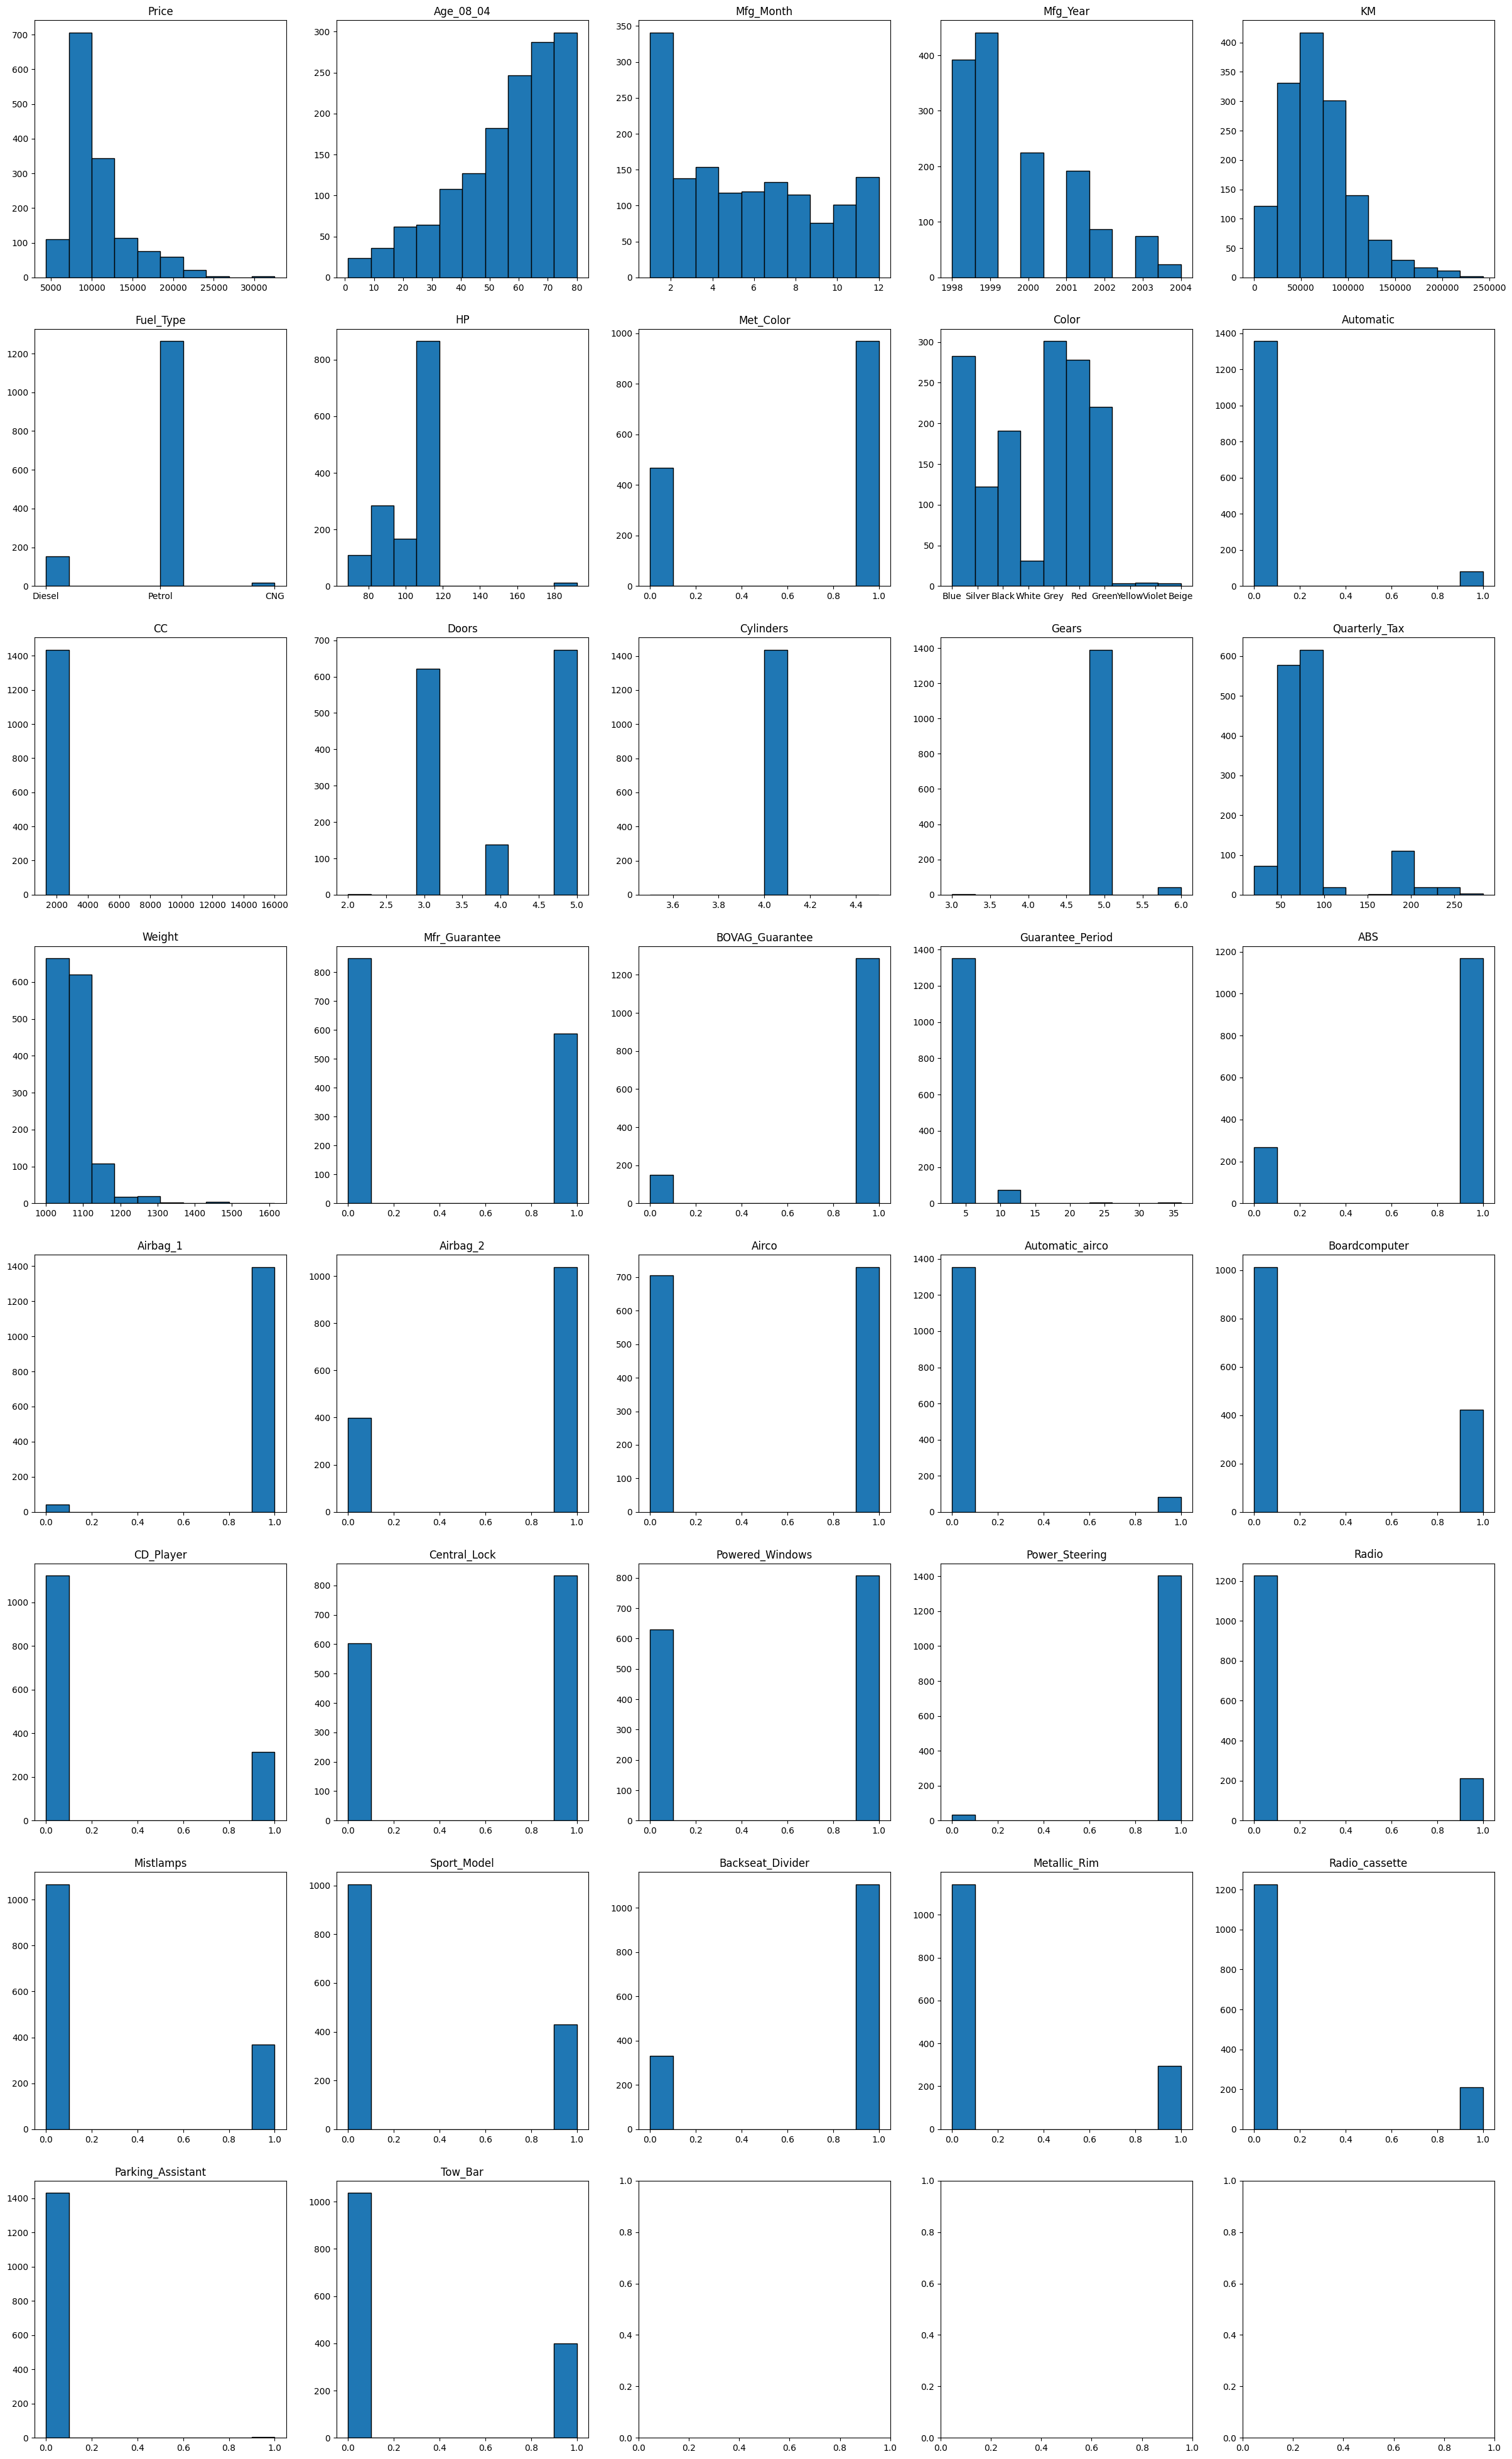

In [65]:
fig, axes = plt.subplots(8, 5, figsize=(30, 50))

it = 0

for col in df.drop(['Id', 'Model'], axis=True).columns: # Нету смысла строить гистограмму у признаков, у которых все значения уникальны, по типу Id, Либо полной модели 

    x_i = int(it%5)
    y_i = int(it/5)

    axes[y_i, x_i].hist(data=df, x = col, edgecolor='black')
    axes[y_i, x_i].set_title(col)


    it += 1

Тепловая карта корреляций

<Axes: >

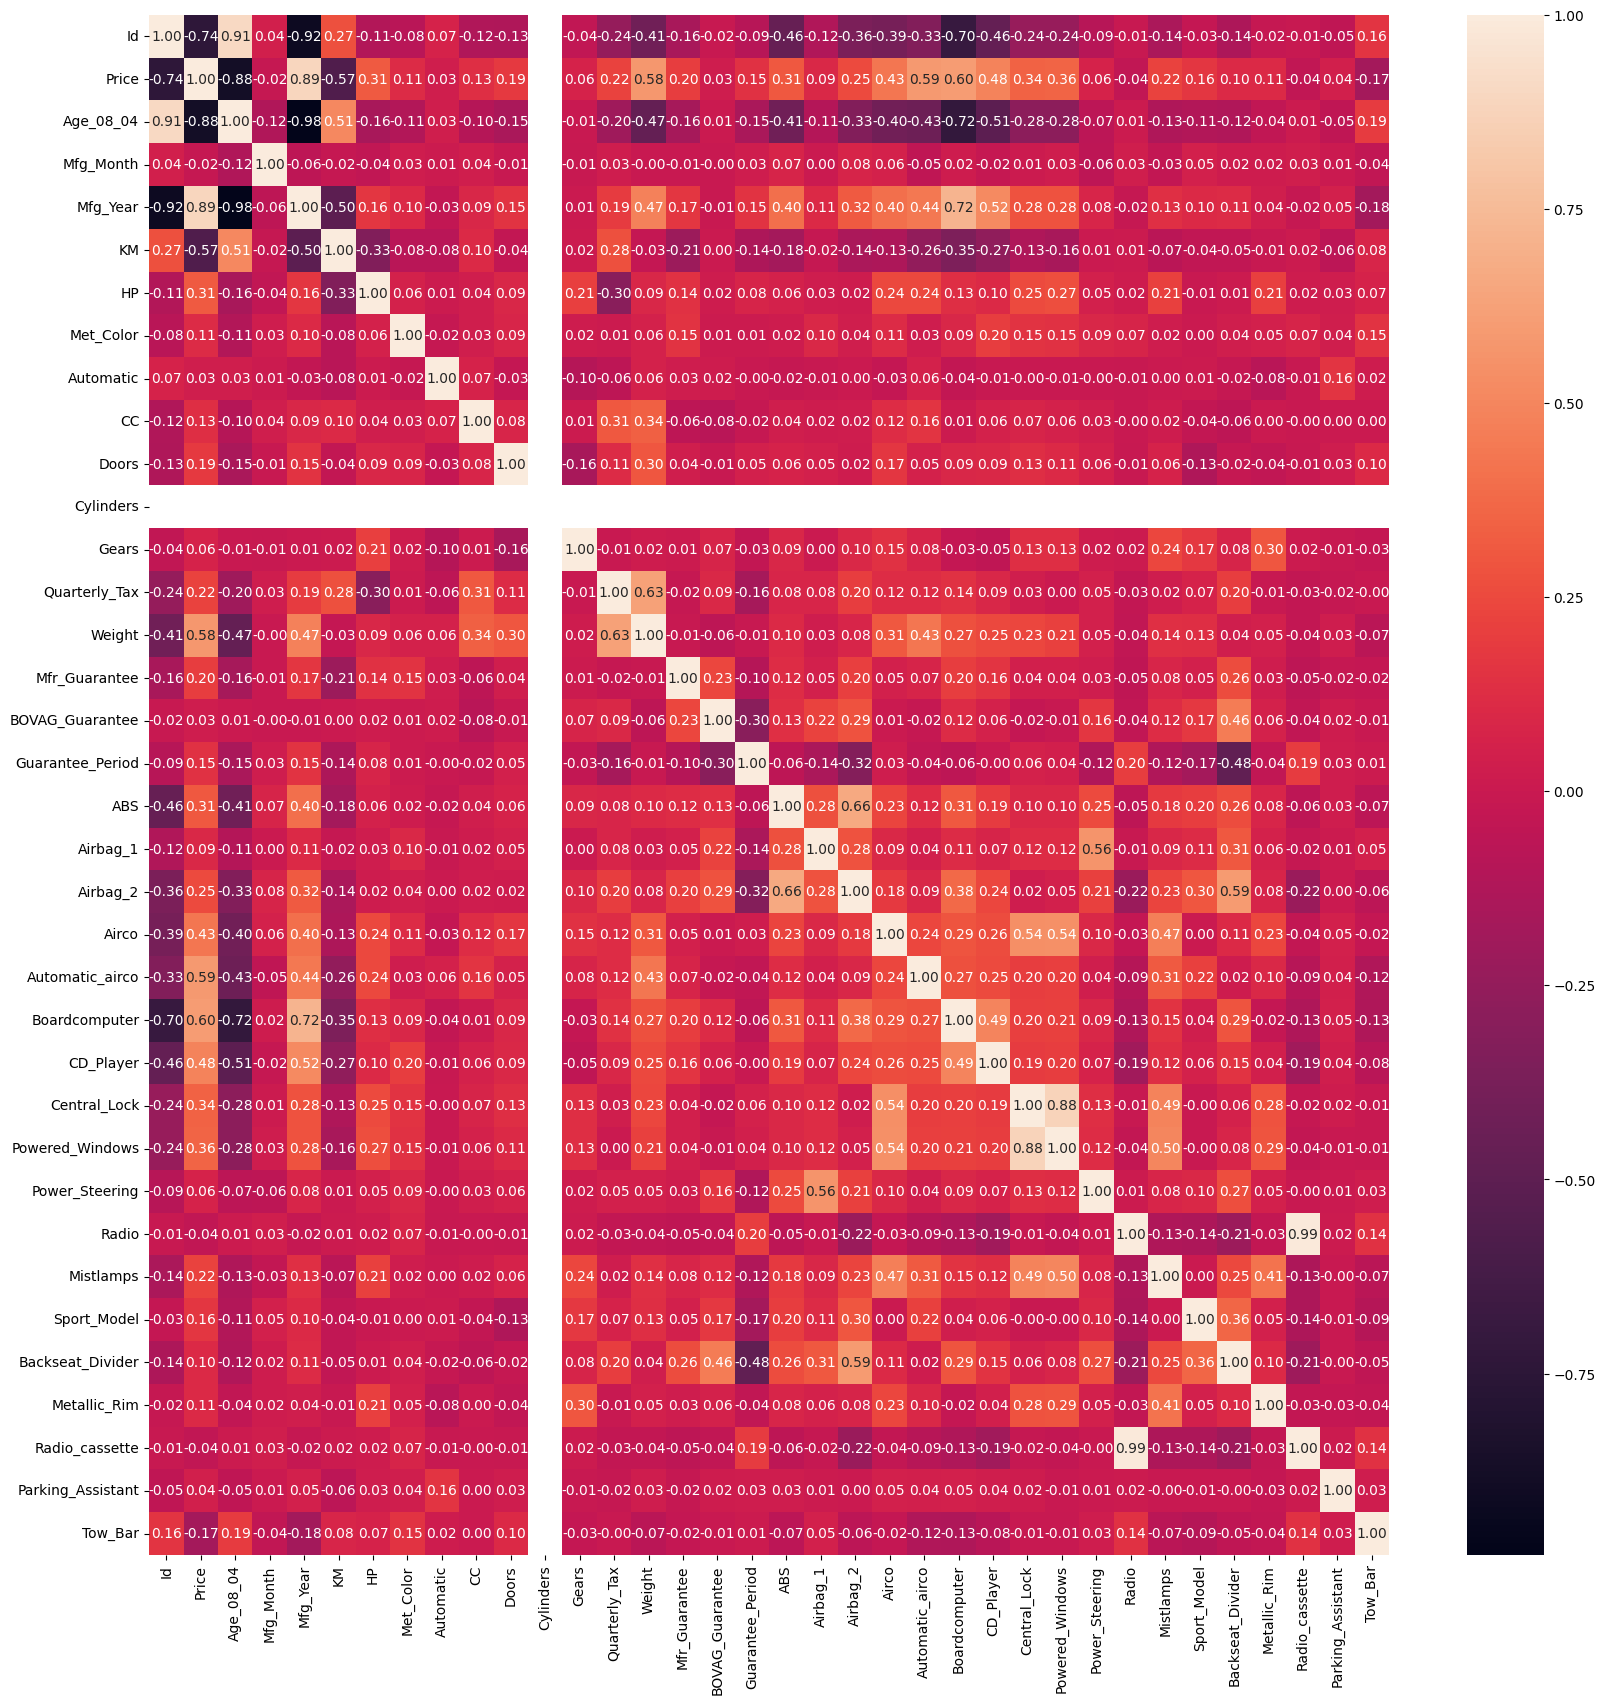

In [66]:
corr_ma = df.drop(['Model', 'Color', 'Fuel_Type'], axis=1).corr()

fig, ax = plt.subplots(figsize=(20, 20)) 

sns.heatmap(corr_ma, annot=True, fmt='.2f')

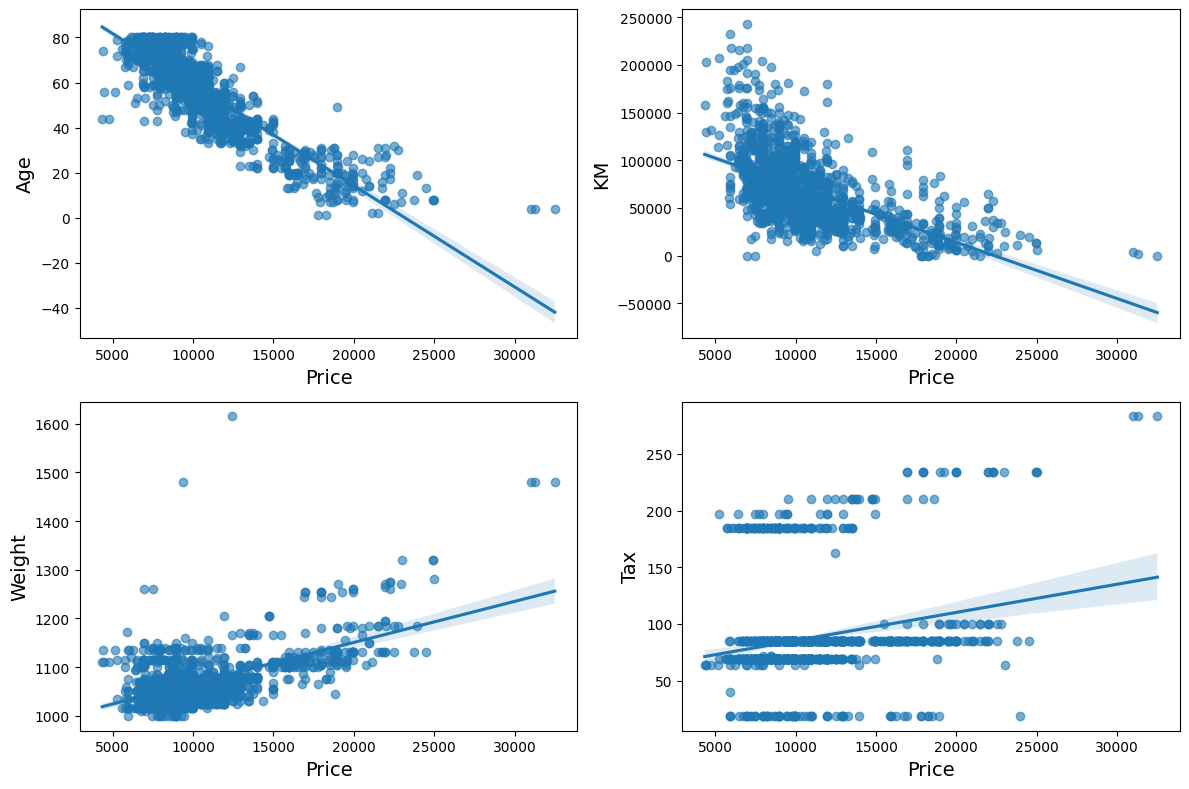

In [67]:
f, axes = plt.subplots(2, 2, figsize=(12,8))

sns.regplot(x='Price', y='Age_08_04', data=df, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('Price', fontsize=14)
axes[0,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='KM', data=df, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('Price', fontsize=14)
axes[0,1].set_ylabel('KM', fontsize=14)

sns.regplot(x='Price', y='Weight', data=df, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('Price', fontsize=14)
axes[1,0].set_ylabel('Weight', fontsize=14)

sns.regplot(x='Price', y='Quarterly_Tax', data=df, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('Price', fontsize=14)
axes[1,1].set_ylabel('Tax', fontsize=14)

plt.tight_layout()
plt.show()

Итак, из EDA, было выявлено:
- Radio и Radio_cassette дублируют друг друга, один из них следует **удалить**.
- ID не несёт никакой информативности, его так же **удалим**.
- Age_08_04 по сути состоит из информации **Mfg_years, Mfg_month, Эти два признака можно будет удалить**, а Age_08_04 оставить(Или если обосновать это аналитично, то Mfg_years дублирует Age_08_04(0.98 корреляции)
- Все признаки с малой корреляцией удалим!

 


на таргет(Price) влияет больше всего:
- Аge_08_04(Коррелирует отрицательно, логично, чем новее машина, тем она дороже)
- Weight(Логично, т.к. при увеличении массы расход топлива больше, а такую машину иметь невыгодно)
- KM (пробег, тоже логично, отрицательно коррелирует)
- Некоторые опции(Airco, Automatic_airco, Boardcomputer, CD_player и т.д.)

# <center>Feature Engineering</center>

In [68]:
columns_to_drop = list(corr_ma[abs(corr_ma['Price']) < 0.2].index)

columns_to_drop.extend(['Radio_cassette', 'Id', 'Mfg_Year', 'Color', 'Model']) # Удалим эти столбцы

df = df.drop(columns_to_drop, axis=True)

In [69]:
df = pd.get_dummies(data=df, columns=['Fuel_Type'])

print(df.head())

   Price  Age_08_04     KM  HP  Cylinders  Quarterly_Tax  Weight  ABS  \
0  13500         23  46986  90          4            210    1165    1   
1  13750         23  72937  90          4            210    1165    1   
2  13950         24  41711  90          4            210    1165    1   
3  14950         26  48000  90          4            210    1165    1   
4  13750         30  38500  90          4            210    1170    1   

   Airbag_2  Airco  Automatic_airco  Boardcomputer  CD_Player  Central_Lock  \
0         1      0                0              1          0             1   
1         1      1                0              1          1             1   
2         1      0                0              1          0             0   
3         1      0                0              1          0             0   
4         1      1                0              1          0             1   

   Powered_Windows  Mistlamps  Fuel_Type_CNG  Fuel_Type_Diesel  \
0                1  

<Axes: >

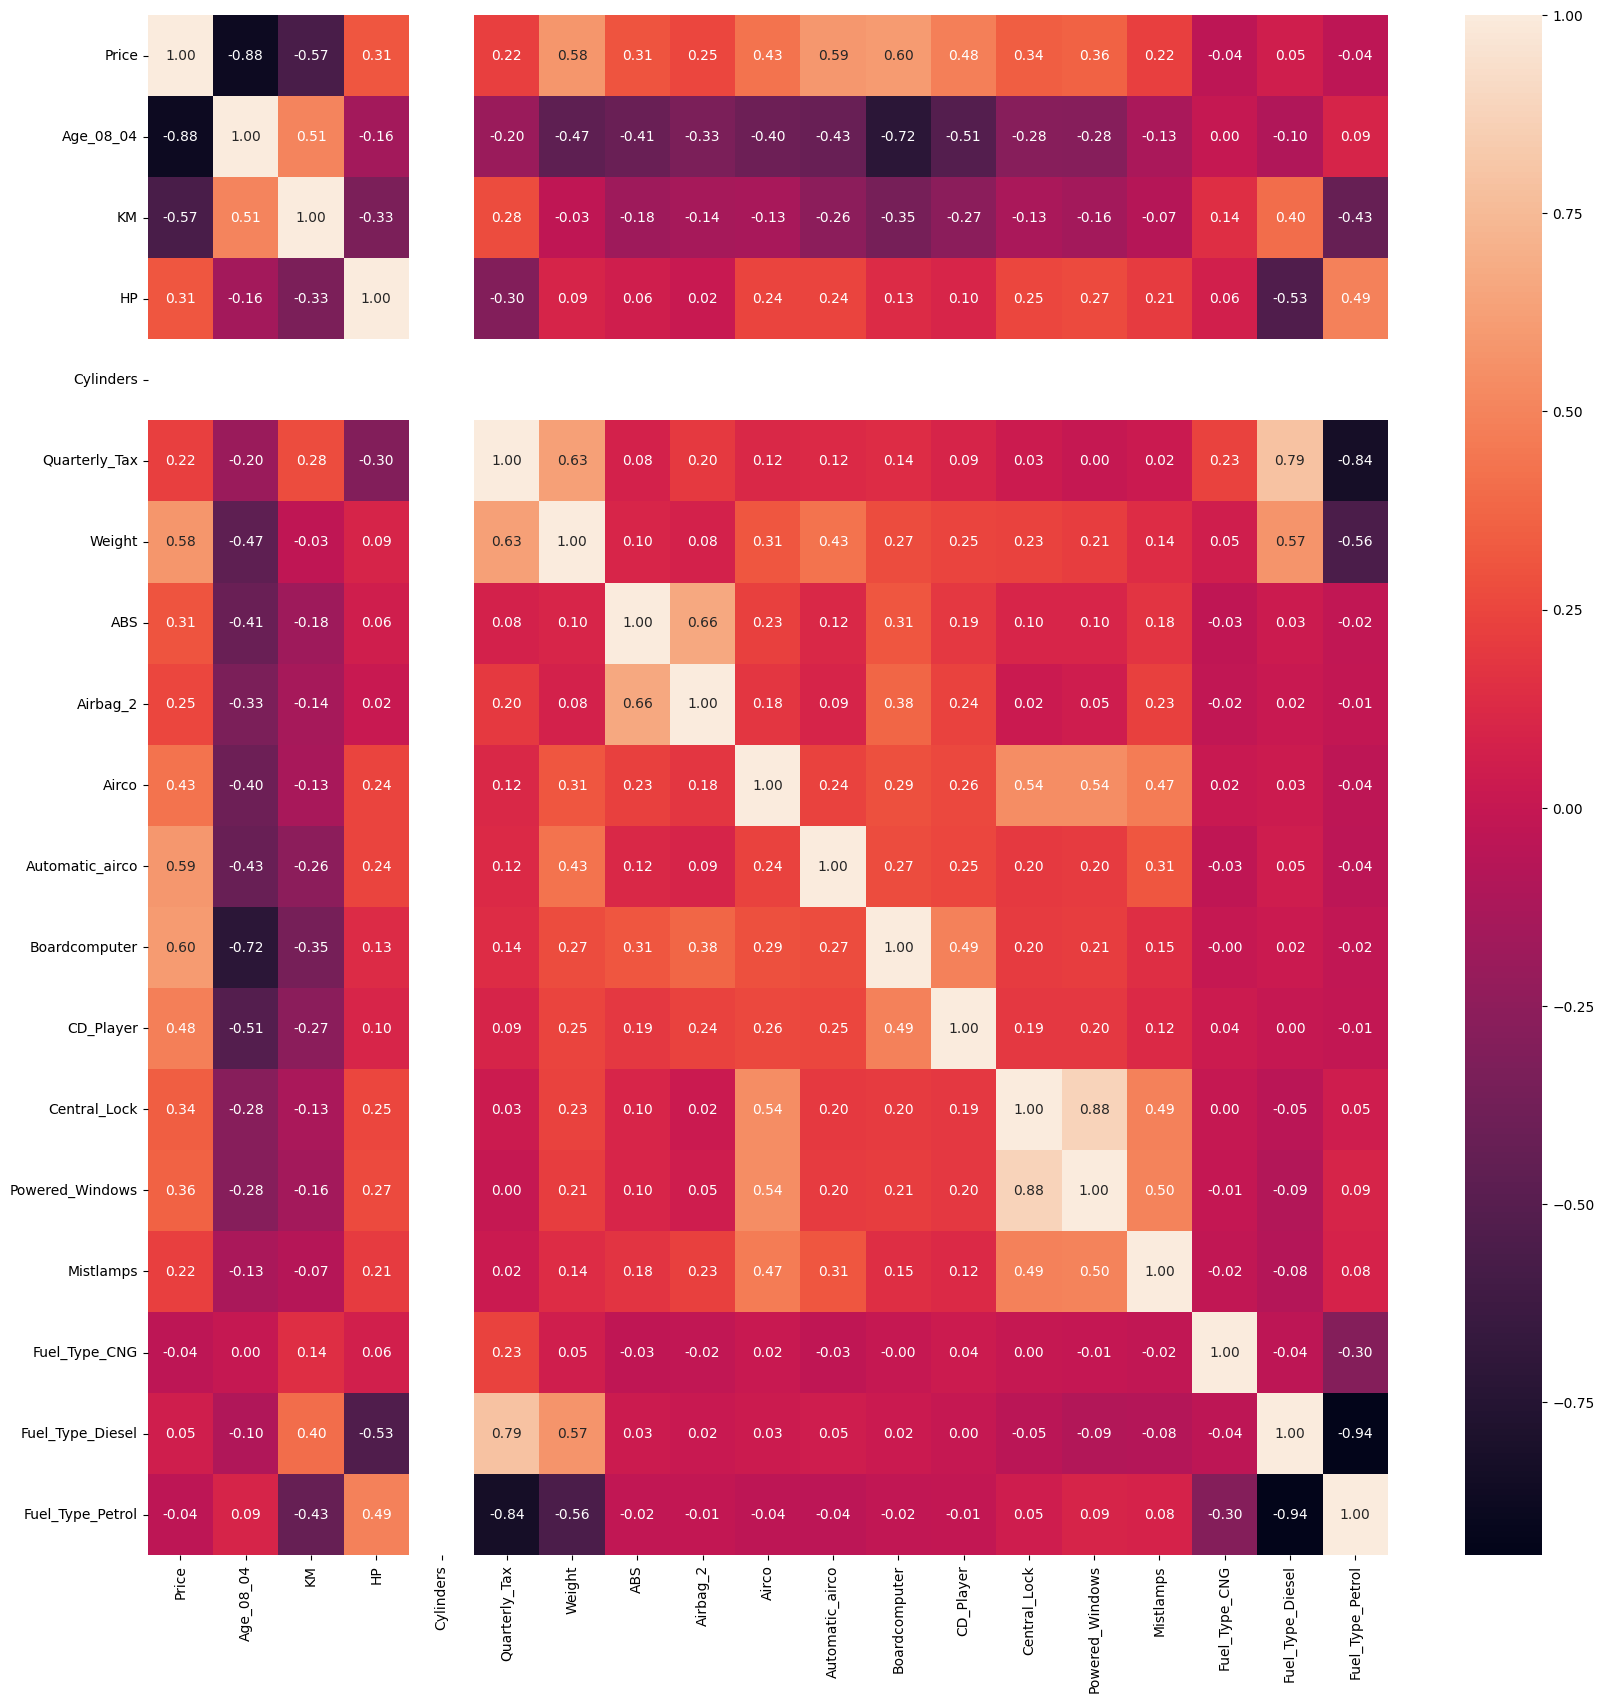

In [70]:
corr_ma = df.corr()

fig, ax = plt.subplots(figsize=(20, 20)) 

sns.heatmap(corr_ma, annot=True, fmt='.2f')

Оказывается, тип топлива тоже не особо влияет на цену - УДАЛЯЕМ!

In [71]:
df = df.drop(['Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'], axis=True)

In [72]:
X = df.drop('Price', axis=True)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [73]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  0.8808052211115003
R2_score (train):  0.9301245151492102
R2_score (test):  0.8894538809559815
RMSE:  1252.4965384042946
MAPE:  0.09051860249397256


## Lasso регуляризация

In [74]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=2, max_iter=10000))
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  0.8933776825726818
R2_score (train):  0.922391128578238
R2_score (test):  0.9164846426491656
RMSE:  1088.6491954508033
MAPE:  0.08412007111463139


## Ridge регуляризация

In [75]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=2, max_iter=10000))
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  0.891568497429807
R2_score (train):  0.9246290732761338
R2_score (test):  0.9121585644022451
RMSE:  1116.4891231138033
MAPE:  0.08570129999355004


## Elastic Net регуляризация

In [76]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', ElasticNet(alpha=2, max_iter=10000))
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  0.8742174405246195
R2_score (train):  0.8870625661544473
R2_score (test):  0.8986018499281632
RMSE:  1199.553990816385
MAPE:  0.08937840488643162
